Importing the basic libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


Importing the dataset

In [3]:
dataset = pd.read_csv('dataset.csv')

In [6]:
dataset.head()

,INCOME,SPEND
0,233,150
1,250,187
2,204,172
3,236,178
4,354,163


Summarize Dataset

In [4]:
dataset.shape


(303, 2)

In [5]:
dataset.describe()


,INCOME,SPEND
count,303.000000,303.000000
mean,245.273927,149.646865
std,48.499412,22.905161
min,126.000000,71.000000
25%,211.000000,133.500000
50%,240.000000,153.000000
75%,274.000000,166.000000
max,417.000000,202.000000


In [7]:
dataset.head(5)

,INCOME,SPEND
0,233,150
1,250,187
2,204,172
3,236,178
4,354,163


Segregate & Zipping Dataset

In [8]:
Income = dataset['INCOME'].values
Spend = dataset['SPEND'].values
X = np.array(list(zip(Income, Spend)))

Finding the Optimized K Value

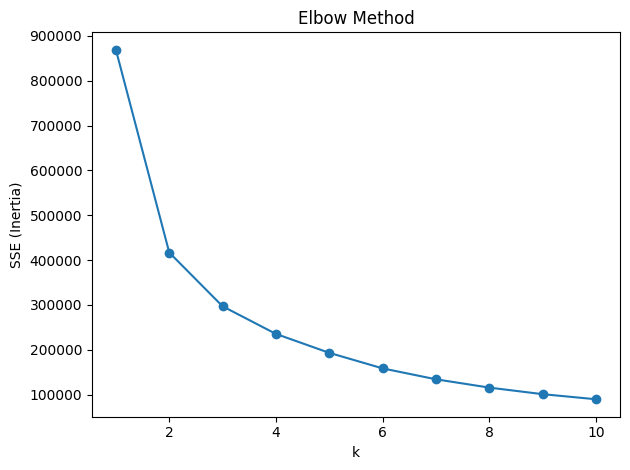

In [9]:
from sklearn.cluster import KMeans
K_MAX = 10
sse = []
for k in range(1, K_MAX+1):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    sse.append(km.inertia_)

plt.figure()
plt.plot(range(1, K_MAX+1), sse, marker='o')
plt.xlabel("k")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()

Fitting the k-means to the dataset with k=4

In [12]:
model=KMeans(n_clusters=3, random_state=0)
y_means = model.fit_predict(X)

** Visualizing the clusters for k=4**

Cluster 1: Customers with medium income and low spend

Cluster 2: Customers with high income and medium to high spend

Cluster 3: Customers with low income

Cluster 4: Customers with medium income but high spend

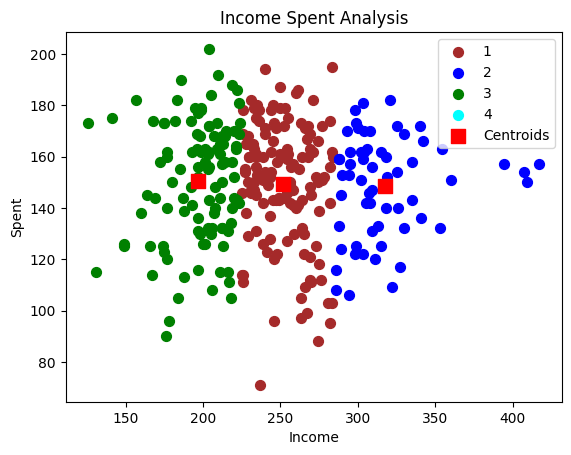

In [13]:
plt.scatter(X[y_means==0,0],X[y_means==0,1],s=50, c='brown',label='1')
plt.scatter(X[y_means==1,0],X[y_means==1,1],s=50, c='blue',label='2')
plt.scatter(X[y_means==2,0],X[y_means==2,1],s=50, c='green',label='3')
plt.scatter(X[y_means==3,0],X[y_means==3,1],s=50, c='cyan',label='4')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1],s=100,marker='s', c='red', label='Centroids')
plt.title('Income Spent Analysis')
plt.xlabel('Income')
plt.ylabel('Spent')
plt.legend()
plt.show()